# $\chi^2$ tests

**Correct formula to use:**
$$
    \chi^2 = \sum_i^N \frac{(\tilde{y_i} - y_i)^2}{\sigma^2_{\tilde{y_i}}}
$$
where $\tilde{y_i}$ is the (noisy) prediction, $y_i$ is the true/expected signal, and $\sigma_{\tilde{y_i}}$ is the shot noise of the predicted signal (or measured signal) -- $\sigma_{\tilde{y_i}} = \sigma_e^2/ \rm counts$.

**Which counts do they correspond to?** Lens, source, both?

In [ ]:
import sys
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from pathlib import Path
import sys

# Absolute path to the emu directory
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
# change folder to parent directory
os.chdir("../../")

import predict
import load_data

I0000 00:00:1788512160.014339 3385554 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788512160.015097 3385554 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788512160.091781 3385554 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788512161.405794 3385554 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [ ]:
cwd = Path.cwd() 
print("Current Working Directory:", cwd) 

Current Working Directory: /home/s2561233/Documents/lss/ridges/ridges_toolkit


Collect all data

In [ ]:
# get radial bins, mean and stdev from metadata
with open('emu/data/metadata.json', 'r') as f:
    metadata = json.load(f)

sep_bin_center = metadata['sep_bin_center']
radial_bins = metadata['radial_bins']
lens_bins = metadata['lens_bins']
source_bins = metadata['source_bins']

# choose one simulation as true data
idx = 50 # check 23 (very bad)

all_pairs = metadata["bin_pairs"]
print(all_pairs)
# mycolors = ["#930101", "#ff0000", "#ff6969", "#02149c", "#253fff", "#7888ff", "#27910f", "#7cff5f", "#00FBFF"]
mycolors = ["#940014", "#FF7083", "#FFA9B4", "#18698F", "#599FBA", "#99D4E5", "#7AC011", "#50711E", "#FFDD03"]
npairs = len(all_pairs)

[[0, 1], [0, 2], [0, 3], [1, 1], [1, 2], [1, 3], [2, 2], [2, 3], [3, 3]]


In [ ]:
# load counts from file
readfile = np.genfromtxt('emu/data/counts.txt', unpack=False)
print(readfile.shape)

nsim, l, s, counts = readfile[:,0], readfile[:,1], readfile[:,2], readfile[:,3:]
print(counts.shape)
# counts as function of theta, one number per each simulation and redshift bin combination

(450, 23)
(450, 20)


In [ ]:
sigma_e = 0.26

# We're analysing for one simulation only (idx=0 in previous cells)
# and we know that each simulation number repeats as many times as are the allowed bin pais
# we can use the counts with indicies between idx and idx+n_pairs (as first index,
# the second one refers to the radius)
gal_per_sqarcmn = counts[idx:idx+npairs,:]

shotnoise = sigma_e**2 / gal_per_sqarcmn 

Calculate $\chi^2$

In [ ]:
chi2_notsummed = np.zeros((npairs, radial_bins)) 
label_plot_chi2 = []

for pair_idx, (l, s) in enumerate(all_pairs):
    model_path = 'emu/models/lens' + str(l) + '_source' + str(s) + '.keras'
    X_test, Y_test, shot_noise = load_data.load_dataset(l, s)
    prediction = predict.make_prediction(X_test, l, s, model_path)

    chi2_notsummed[pair_idx] = (prediction[idx] - Y_test[idx])**2 / shotnoise[pair_idx]
    print(f'(l{l}, s{s})')
    label_plot_chi2.append(f'(l{l}, s{s})')

E0000 00:00:1788512162.369877 3385554 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


77/77 - 0s - 4ms/step
(l0, s1)
77/77 - 0s - 3ms/step
(l0, s2)
77/77 - 0s - 3ms/step
(l0, s3)
77/77 - 0s - 2ms/step
(l1, s1)
77/77 - 0s - 2ms/step
(l1, s2)
77/77 - 0s - 2ms/step
(l1, s3)
77/77 - 0s - 2ms/step
(l2, s2)
77/77 - 0s - 2ms/step
(l2, s3)
77/77 - 0s - 2ms/step
(l3, s3)


(9, 20)


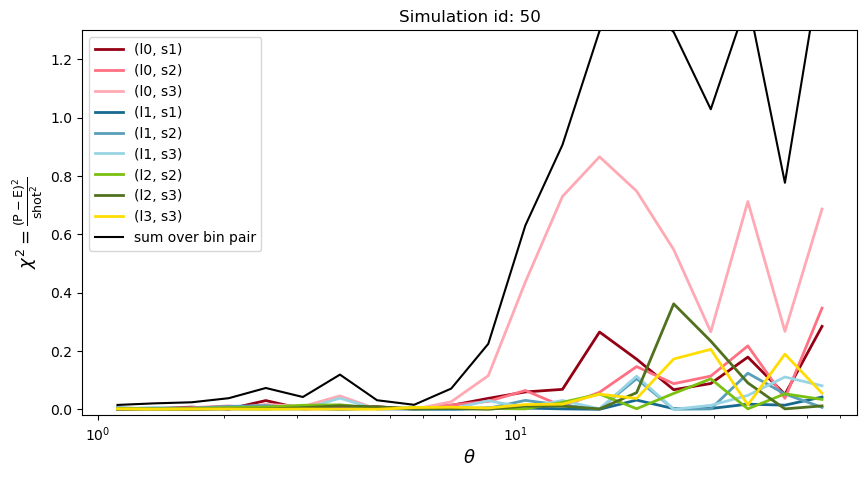

In [ ]:
print(chi2_notsummed.shape)
rc('text', usetex=False)
# rc('font',**{'family':'serif','serif':['Times']})

plt.figure(figsize=(10, 5))
for i in range(npairs):
    plt.plot(sep_bin_center, chi2_notsummed[i], label=label_plot_chi2[i], color=mycolors[i], linewidth=2)
plt.plot(sep_bin_center, np.sum(chi2_notsummed,axis=0), color='k', label='sum over bin pair')
plt.xscale('log')
plt.xlabel(r'$\theta$', fontsize=13)
plt.ylabel(r'$\chi^2 = \rm \frac{(P - E)^2}{shot^2}$', fontsize=13)
plt.ylim(-0.02, 1.3)
plt.title(f'Simulation id: {idx}')
plt.legend()
plt.show()


Text(0.5, 1.0, 'Summed over $\\theta$')

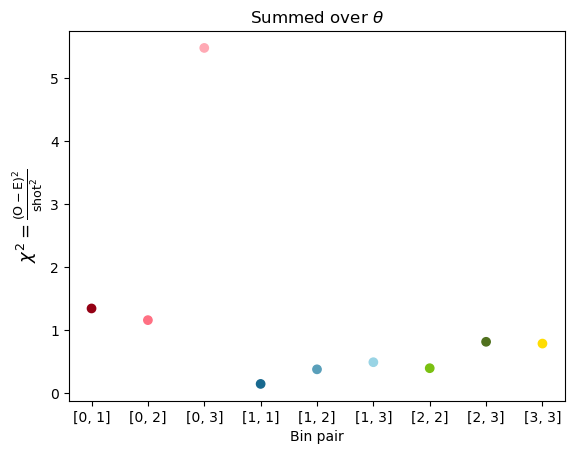

In [ ]:
plt.figure()
x_plot = np.linspace(0, 1., len(chi2_notsummed))
plt.scatter(x_plot, np.sum(chi2_notsummed, axis=1), color=mycolors)
plt.xticks(x_plot, labels=all_pairs)
plt.xlabel('Bin pair')
plt.ylabel(r'$\chi^2 = \rm \frac{(O - E)^2}{shot^2}$', fontsize=13)
plt.title(r'Summed over $\theta$')

In [ ]:
np.sum(chi2_notsummed)

np.float64(10.970660919549145)